# Confronto Architetture — ResNet-50 (224×224) vs MaxViT-Tiny-512 (512×512)

Domanda: **un classificatore realmente 512×512 (MaxViT-Tiny, timm) batte il classificatore ResNet-50
a 224×224 usato nel resto del progetto?**

Confronta, sullo stesso test set reale (438 immagini: 365 sane, 73 malate) e sulle stesse tre configurazioni
di training, le metriche già calcolate da:
- [`09_Test_Classificatori.ipynb`](09_Test_Classificatori.ipynb) → `results/classifiers/resnet50/01y_test/tables/test_metrics.json` (ResNet-50)
- [`17_Test_Classificatori_MaxViT512.ipynb`](17_Test_Classificatori_MaxViT512.ipynb) → `results/classifiers/maxvit512/02x_test/tables/test_metrics.json` (MaxViT-Tiny-512)

Nessun training viene eseguito qui: il notebook si limita a caricare le due tabelle di metriche già
salvate su disco e a confrontarle. Eseguire prima `09` e `17`.

In [1]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os
import sys

# Controlla se il notebook sta girando su Google Colab
# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e BASE sono gia' definiti dal bootstrap
# unificato in cima al notebook.
print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import librerie

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Caricamento Metriche

In [3]:
RESNET_METRICS_PATH  = os.path.join(BASE_PATH, 'results', 'classifiers/resnet50/01y_test', 'tables', 'test_metrics.json')
MAXVIT_METRICS_PATH  = os.path.join(BASE_PATH, 'results', 'classifiers/maxvit512/02x_test', 'tables', 'test_metrics.json')

OUTPUT_DIR  = os.path.join(BASE_PATH, 'results', 'comparisons/classifiers/03z_resnet50_vs_maxvit512')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR  = os.path.join(OUTPUT_DIR, 'tables')
for d in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR):
    os.makedirs(d, exist_ok=True)

assert os.path.isfile(RESNET_METRICS_PATH), (
    f"Metriche ResNet-50 non trovate in {RESNET_METRICS_PATH}. Esegui prima 09_Test_Classificatori.ipynb."
)
assert os.path.isfile(MAXVIT_METRICS_PATH), (
    f"Metriche MaxViT-512 non trovate in {MAXVIT_METRICS_PATH}. Esegui prima 17_Test_Classificatori_MaxViT512.ipynb."
)

with open(RESNET_METRICS_PATH) as f:
    metrics_resnet = json.load(f)
with open(MAXVIT_METRICS_PATH) as f:
    metrics_maxvit = json.load(f)

CONFIGS = ['Baseline', 'Real+Synth', 'Full_Synth']
METRIC_KEYS = ['auc', 'accuracy', 'precision', 'recall', 'f1']
print("Configurazioni disponibili ResNet-50:", list(metrics_resnet.keys()))
print("Configurazioni disponibili MaxViT-512:", list(metrics_maxvit.keys()))

Configurazioni disponibili ResNet-50: ['Baseline', 'Real+Synth', 'Full_Synth']
Configurazioni disponibili MaxViT-512: ['Baseline', 'Real+Synth', 'Full_Synth']


#### Tabella Comparativa per Configurazione

In [4]:
righe = []
for cfg in CONFIGS:
    if cfg not in metrics_resnet or cfg not in metrics_maxvit:
        print(f"Configurazione '{cfg}' mancante in uno dei due esperimenti, salto.")
        continue
    for metrica in METRIC_KEYS:
        v_resnet = metrics_resnet[cfg][metrica]
        v_maxvit = metrics_maxvit[cfg][metrica]
        righe.append({
            'Configurazione': cfg,
            'Metrica': metrica.upper(),
            'ResNet-50 (224x224)': v_resnet,
            'MaxViT-512 (512x512)': v_maxvit,
            'Delta (MaxViT - ResNet)': round(v_maxvit - v_resnet, 4),
            'MaxViT vince': v_maxvit > v_resnet,
        })

df_confronto = pd.DataFrame(righe)
confronto_path = os.path.join(TABLES_DIR, 'confronto_resnet50_vs_maxvit512.csv')
df_confronto.to_csv(confronto_path, index=False)
display(df_confronto)
print(f"Tabella salvata in: {confronto_path}")

,Configurazione,Metrica,ResNet-50 (224x224),MaxViT-512 (512x512),Delta (MaxViT - ResNet),MaxViT vince
0,Baseline,AUC,0.5494,0.6124,0.0630,True
1,Baseline,ACCURACY,0.5320,0.5068,-0.0252,False
2,Baseline,PRECISION,0.1857,0.2033,0.0176,True
3,Baseline,RECALL,0.5342,0.6712,0.1370,True
4,Baseline,F1,0.2756,0.3121,0.0365,True
5,Real+Synth,AUC,0.6120,0.6210,0.0090,True
6,Real+Synth,ACCURACY,0.5274,0.6758,0.1484,True
7,Real+Synth,PRECISION,0.2035,0.2553,0.0518,True
8,Real+Synth,RECALL,0.6301,0.4932,-0.1369,False
9,Real+Synth,F1,0.3077,0.3364,0.0287,True


Tabella salvata in: ../results/21_confronto_resnet50_vs_maxvit512/tables/confronto_resnet50_vs_maxvit512.csv


#### Verdetto — Il classificatore 512×512 batte ResNet-50?

In [5]:
df_auc = df_confronto[df_confronto['Metrica'] == 'AUC']
n_config_vinte = int(df_auc['MaxViT vince'].sum())
n_config_totali = len(df_auc)
delta_auc_medio = df_auc['Delta (MaxViT - ResNet)'].mean()

print(f"MaxViT-512 ha un AUC piu' alto in {n_config_vinte}/{n_config_totali} configurazioni.")
print(f"Delta medio di AUC (MaxViT - ResNet): {delta_auc_medio:+.4f}")

if n_config_vinte == n_config_totali:
    verdetto = "MaxViT-Tiny-512 batte ResNet-50 in TUTTE le configurazioni testate (AUC)."
elif n_config_vinte == 0:
    verdetto = "ResNet-50 batte MaxViT-Tiny-512 in TUTTE le configurazioni testate (AUC)."
else:
    verdetto = f"Risultato misto: MaxViT-512 vince in {n_config_vinte}/{n_config_totali} configurazioni (AUC)."

print("\nVERDETTO:", verdetto)

verdetto_dict = {
    'n_config_vinte_da_maxvit_auc': n_config_vinte,
    'n_config_totali': n_config_totali,
    'delta_auc_medio': round(float(delta_auc_medio), 4),
    'verdetto': verdetto,
}
with open(os.path.join(TABLES_DIR, 'verdetto.json'), 'w') as f:
    json.dump(verdetto_dict, f, indent=2, ensure_ascii=False)

MaxViT-512 ha un AUC piu' alto in 3/3 configurazioni.
Delta medio di AUC (MaxViT - ResNet): +0.0366

VERDETTO: MaxViT-Tiny-512 batte ResNet-50 in TUTTE le configurazioni testate (AUC).


#### Grafico Comparativo per Configurazione

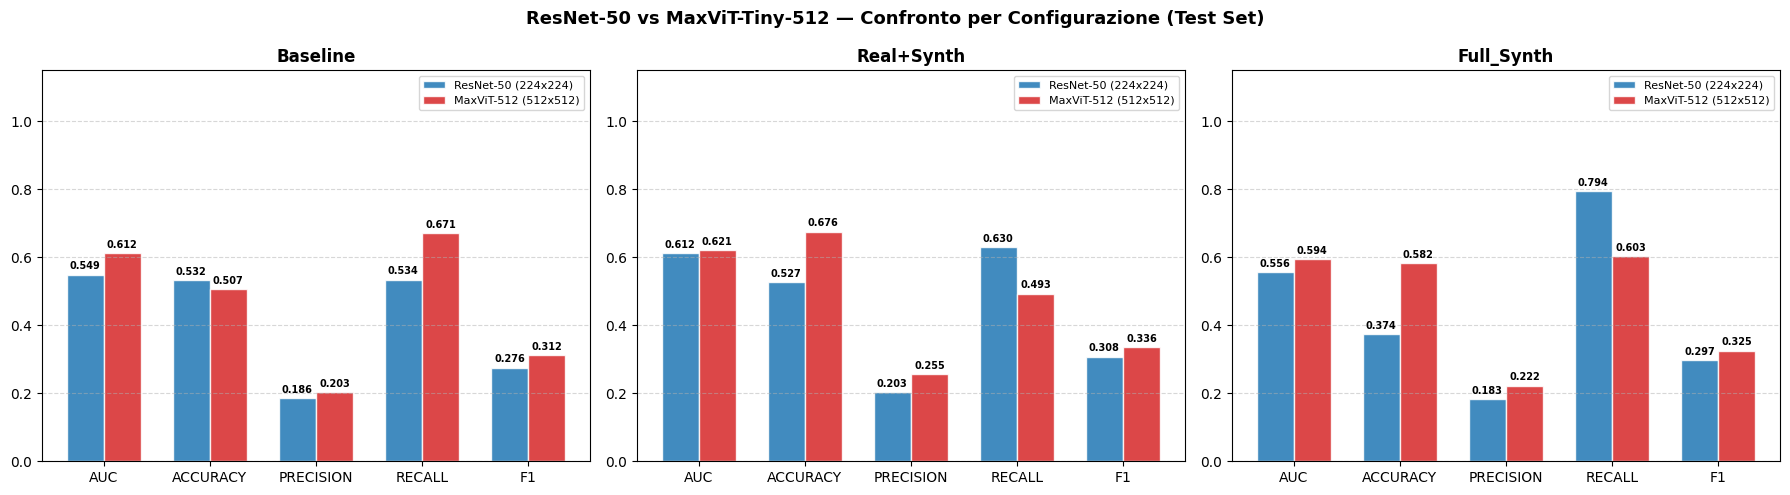

Salvato in: ../results/21_confronto_resnet50_vs_maxvit512/figures/confronto_resnet50_vs_maxvit512.png


In [6]:
configs_disponibili = [c for c in CONFIGS if c in metrics_resnet and c in metrics_maxvit]
fig, axes = plt.subplots(1, len(configs_disponibili), figsize=(6 * len(configs_disponibili), 5), squeeze=False)
axes = axes[0]

x = np.arange(len(METRIC_KEYS))
width = 0.35

for ax, cfg in zip(axes, configs_disponibili):
    vals_resnet = [metrics_resnet[cfg][m] for m in METRIC_KEYS]
    vals_maxvit = [metrics_maxvit[cfg][m] for m in METRIC_KEYS]

    bars1 = ax.bar(x - width/2, vals_resnet, width, label='ResNet-50 (224x224)', color='tab:blue', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, vals_maxvit, width, label='MaxViT-512 (512x512)', color='tab:red', alpha=0.85, edgecolor='white')

    for bars in (bars1, bars2):
        for bar in bars:
            v = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in METRIC_KEYS])
    ax.set_ylim(0, 1.15)
    ax.set_title(cfg, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('ResNet-50 vs MaxViT-Tiny-512 — Confronto per Configurazione (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'confronto_resnet50_vs_maxvit512.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {bar_path}")

#### Delta AUC per Configurazione

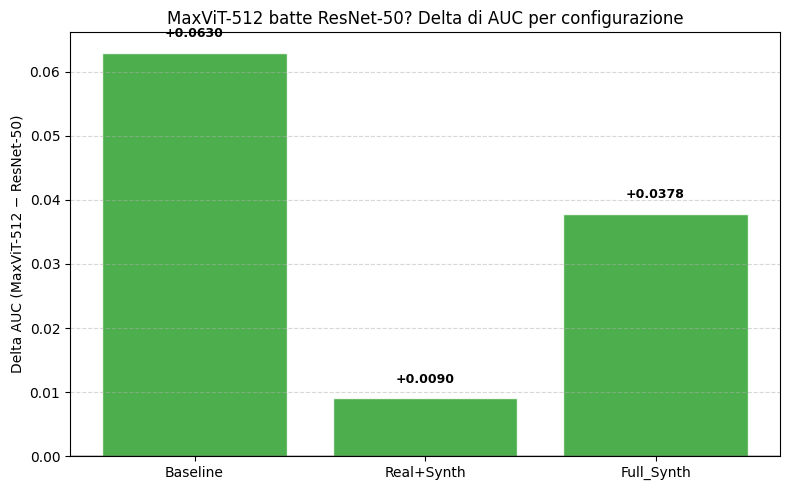

Salvato in: ../results/21_confronto_resnet50_vs_maxvit512/figures/delta_auc_maxvit_vs_resnet.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
deltas = [df_auc[df_auc['Configurazione'] == cfg]['Delta (MaxViT - ResNet)'].iloc[0] for cfg in configs_disponibili]
colors_delta = ['tab:green' if d > 0 else 'tab:red' for d in deltas]
bars = ax.bar(configs_disponibili, deltas, color=colors_delta, alpha=0.85, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=1)
for bar, d in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width()/2, d + (0.002 if d >= 0 else -0.006),
            f'{d:+.4f}', ha='center', va='bottom' if d >= 0 else 'top', fontsize=9, fontweight='bold')
ax.set_ylabel('Delta AUC (MaxViT-512 − ResNet-50)')
ax.set_title('MaxViT-512 batte ResNet-50? Delta di AUC per configurazione')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
delta_path = os.path.join(FIGURES_DIR, 'delta_auc_maxvit_vs_resnet.png')
fig.savefig(delta_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {delta_path}")